In [1]:
from pathlib import Path

import oyaml as yaml
import pandas as pd

from prismadv.data_models.config import PrismaDVConfig
from prismadv.project_manager.manager.base import ProjectManager
from prismadv.utils import get_project_root
import numpy as np

dataset_name_options = ["students", "hr_analytics", "sleep_health", "IPL_win_prediction", "imdb"]
model_order = ["gemini-2.5-flash", "gpt-4.1", "gpt-4o", "gpt-5-mini", "gemini-2.5-pro", "gpt-5"]
unique_subset_cols = [
    "llm_name", "llm_temperature", "use_async",
    "dataset_name", "subtask_name",
    "processed_data_label", "script_name", "is_clean"
]
constraints_on_single_column_only = False
constraint_glob = "post_processed_prismadv--*.yaml"
results_df = pd.DataFrame()
processed_data_label = '0'
for dataset_name in dataset_name_options:
    info_df = pd.DataFrame()
    pm = ProjectManager(project_root=get_project_root(), dataset_name=dataset_name)
    for subtask_name in pm.get_available_subtasks():
        processed_data_labels = pm.get_available_processed_data_labels_for_subtask(subtask_name)
        script_names = [p.stem for p in pm.get_available_script_path_list_for_subtask(subtask_name)]

        for script_name in script_names:
            constraints_path: Path = pm.get_constraints_path(subtask_name, processed_data_label, script_name)
            validation_dir: Path = pm.get_constraints_validation_path(subtask_name, processed_data_label,
                                                                      script_name)

            for constraint_file in constraints_path.glob(constraint_glob):
                with open(constraint_file, "r") as f:
                    raw = yaml.load(f, Loader=yaml.FullLoader)
                    prismadv_config = PrismaDVConfig.from_dict(raw["prismadv_config"])
                    cost_summary = raw.get("cost_summary", {})
                    llm_name = prismadv_config.llm.model_name,
                    llm_temperature = prismadv_config.llm.temperature

                    df_row = {
                        "dataset_name": dataset_name,
                        "script_name": script_name,
                        "llm_name": llm_name,
                        "llm_temperature": llm_temperature,
                        "subtask_name": subtask_name,
                        "processed_data_label": processed_data_label,
                        "cost_summary": cost_summary,
                    }
                    info_df = pd.concat([info_df, pd.DataFrame([df_row])], ignore_index=True)
    results_df = pd.concat([results_df, info_df], ignore_index=True)

In [2]:
cost_keys = ['column_access_detection', 'column_correlation_discovery', 'data_flow_inspection',
             'multi_column_data_flow_inspection', 'single_column_assumption_generation',
             'multi_column_assumption_generation', 'single_column_code_generation', 'multi_column_code_generation',
             'code_fixing', 'consolidate_constraints']

cost_df = pd.DataFrame()
for i in range(len(results_df)):
    cost_summary = results_df.cost_summary[i]
    try:
        df_row = {key: cost_summary.get(key, {})['total_tokens'] for key in cost_keys}
        df_row["dataset_name"] = results_df.dataset_name[i]
        df_row["script_name"] = results_df.script_name[i]
        df_row["llm_name"] = results_df.llm_name[i]
        cost_df = pd.concat([cost_df, pd.DataFrame([df_row])], ignore_index=True)
    except Exception as e:
        continue

In [3]:
agg_df = (
    cost_df
    .groupby(["dataset_name", "llm_name"], as_index=False)[cost_keys]
    .sum()
)

long_df = agg_df.melt(
    id_vars=["dataset_name", "llm_name"],
    value_vars=cost_keys,
    var_name="stage",
    value_name="tokens"
)

# long_df["tokens"] = long_df["tokens"].fillna(0).astype(int)

# 4. Enforce the stage order
long_df["stage"] = pd.Categorical(long_df["stage"], categories=cost_keys, ordered=True)
long_df = long_df.sort_values(["dataset_name", "llm_name", "stage"])

# 5. Compute cumulative (incremental) tokens per dataset + llm
long_df["cum_tokens"] = (
    long_df
    .groupby(["dataset_name", "llm_name"])["tokens"]
    .cumsum()
)

/var/folders/19/8dpm1qss7mn34db1f49thmww0000gn/T/ipykernel_23945/2320210352.py:21: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(long_df["stage"]):
/var/folders/19/8dpm1qss7mn34db1f49thmww0000gn/T/ipykernel_23945/2320210352.py:87: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


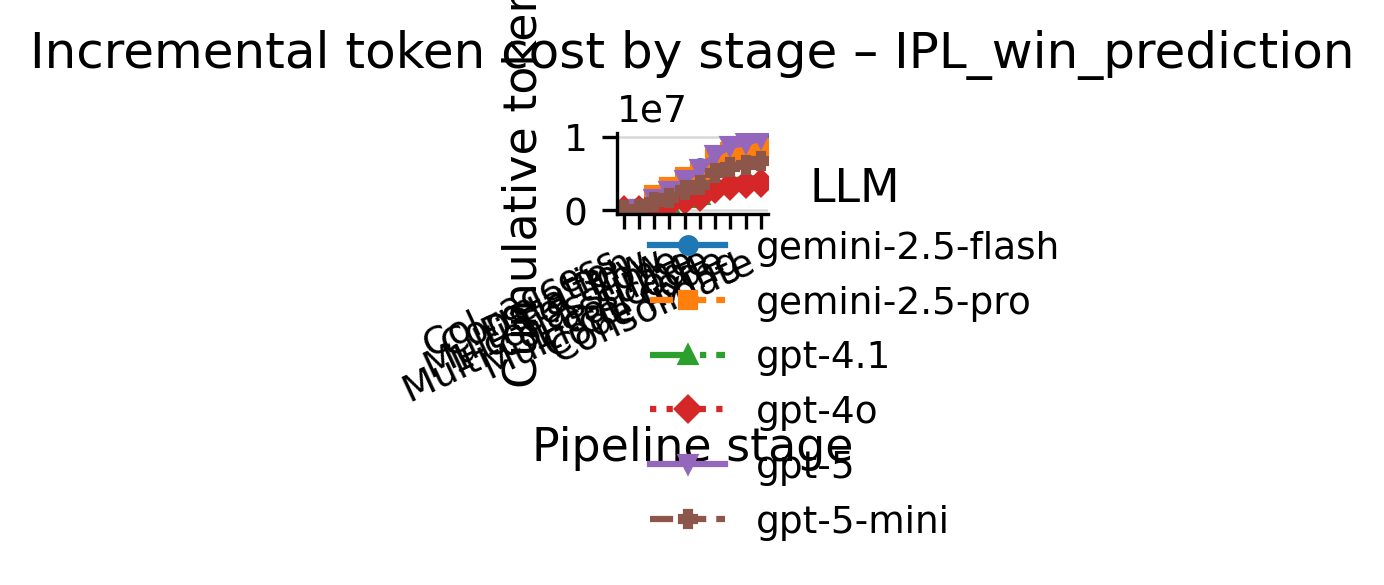

/var/folders/19/8dpm1qss7mn34db1f49thmww0000gn/T/ipykernel_23945/2320210352.py:87: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


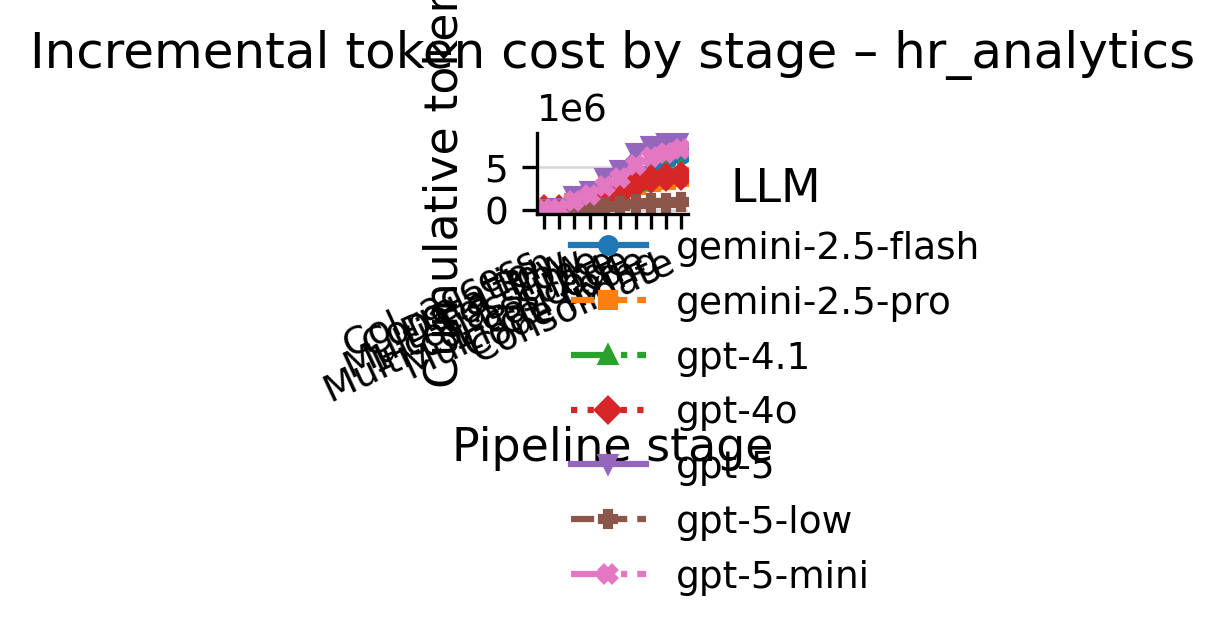

/var/folders/19/8dpm1qss7mn34db1f49thmww0000gn/T/ipykernel_23945/2320210352.py:87: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


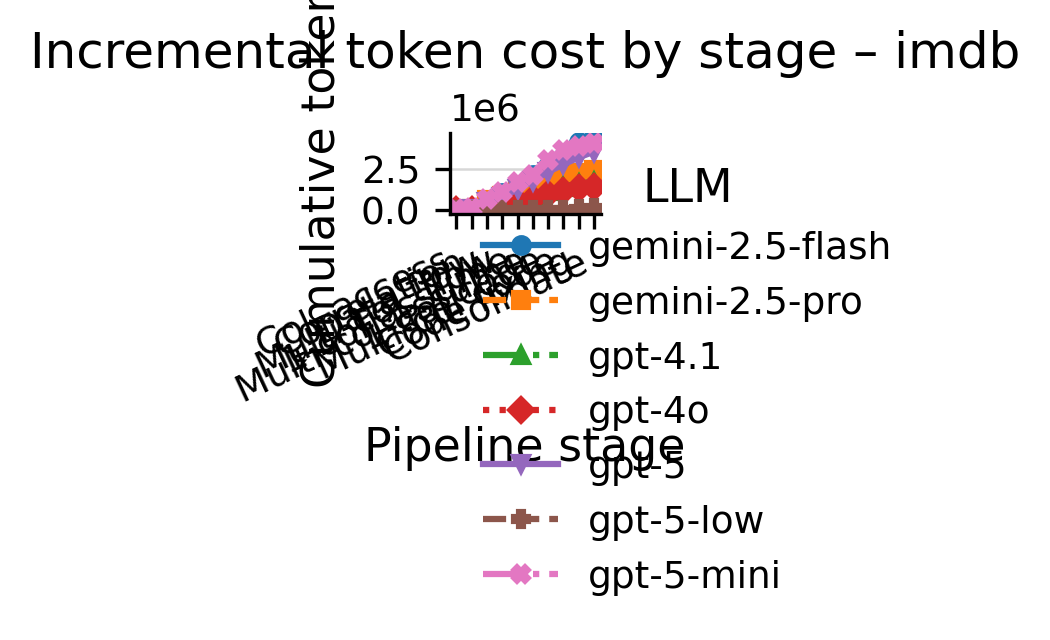

/var/folders/19/8dpm1qss7mn34db1f49thmww0000gn/T/ipykernel_23945/2320210352.py:87: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


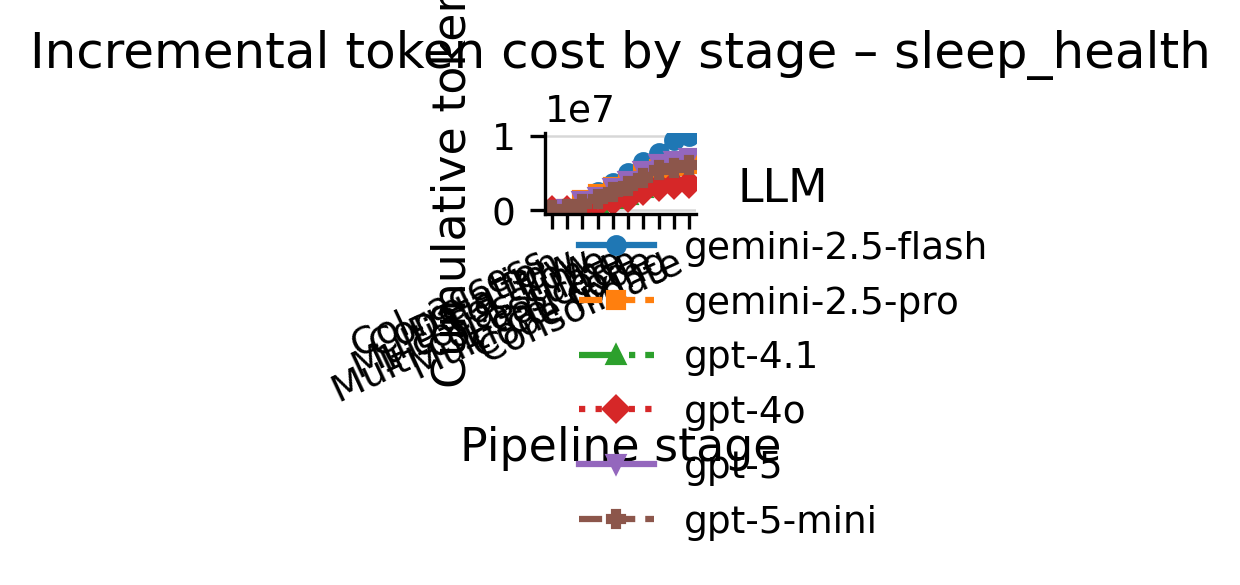

/var/folders/19/8dpm1qss7mn34db1f49thmww0000gn/T/ipykernel_23945/2320210352.py:87: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


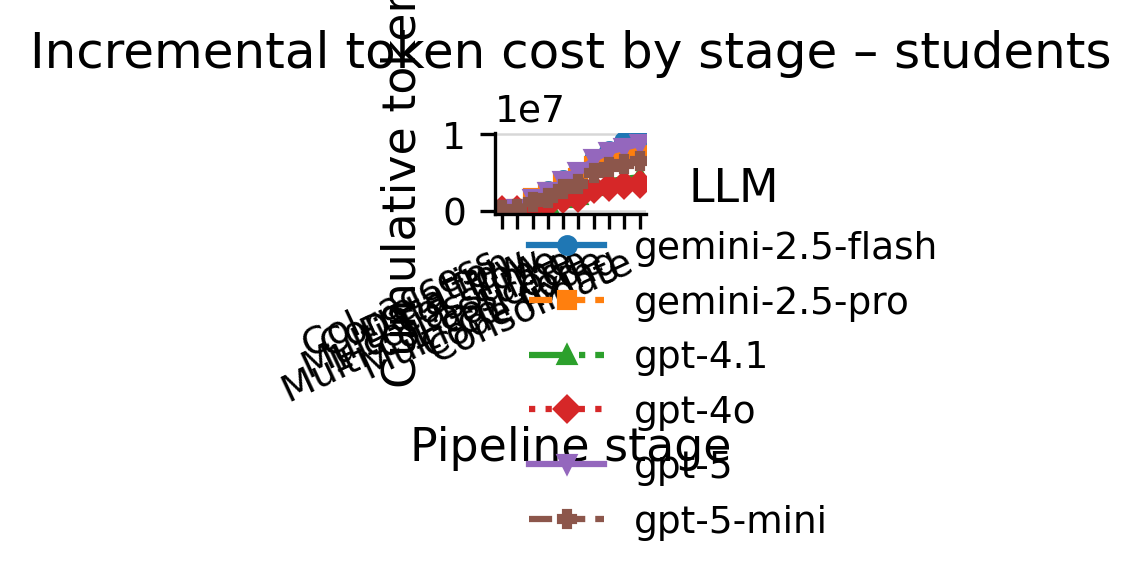

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

# ---------- 1. Global plot style (paper-ready) ----------
mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    # Uncomment if you want Times-like fonts for SIGMOD
    # "font.family": "serif",
    # "font.serif": ["Times New Roman", "Times"],
})

# ---------- 2. Derive stage order from long_df ----------
if pd.api.types.is_categorical_dtype(long_df["stage"]):
    stages = list(long_df["stage"].cat.categories)
else:
    # Fallback: sort by name
    stages = sorted(long_df["stage"].unique())

stage_positions = np.arange(len(stages))

# Optional: nicer labels (only for those stages that exist)
stage_label_map = {
    'column_access_detection': 'Col. access',
    'column_correlation_discovery': 'Correlation',
    'data_flow_inspection': 'Data flow',
    'multi_column_data_flow_inspection': 'Multi-col. flow',
    'single_column_assumption_generation': '1-col assume',
    'multi_column_assumption_generation': 'Multi-col assume',
    'single_column_code_generation': '1-col code',
    'multi_column_code_generation': 'Multi-col code',
    'code_fixing': 'Code fixing',
    'consolidate_constraints': 'Consolidate',
}
x_labels = [stage_label_map.get(s, s) for s in stages]

# ---------- 3. Line styles & markers for LLMs ----------
line_styles = ['solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

# Make sure data is sorted for plotting
long_df = long_df.sort_values(["dataset_name", "llm_name", "stage"])

# ---------- 4. Plot: one figure per dataset ----------
for dataset, df_ds in long_df.groupby("dataset_name"):
    plt.figure(figsize=(0.65, 0.35))

    for i, (llm, df_llm) in enumerate(df_ds.groupby("llm_name")):
        # Align to the global stage order
        df_llm = df_llm.set_index("stage").reindex(stages)

        style = line_styles[i % len(line_styles)]
        marker = markers[i % len(markers)]

        plt.plot(
            stage_positions,
            df_llm["cum_tokens"].values,
            linestyle=style,
            marker=marker,
            linewidth=1.5,
            markersize=4,
            label=llm,
        )

    # Axes / ticks
    plt.xticks(stage_positions, x_labels, rotation=25, ha="right")
    plt.ylabel("Cumulative tokens")
    plt.xlabel("Pipeline stage")
    plt.title(f"Incremental token cost by stage – {dataset}")

    # Grid & spines for a clean look
    plt.grid(True, axis="y", linewidth=0.6, alpha=0.5)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend
    plt.legend(title="LLM", frameon=False, loc="upper left")

    plt.tight_layout()
    plt.show()

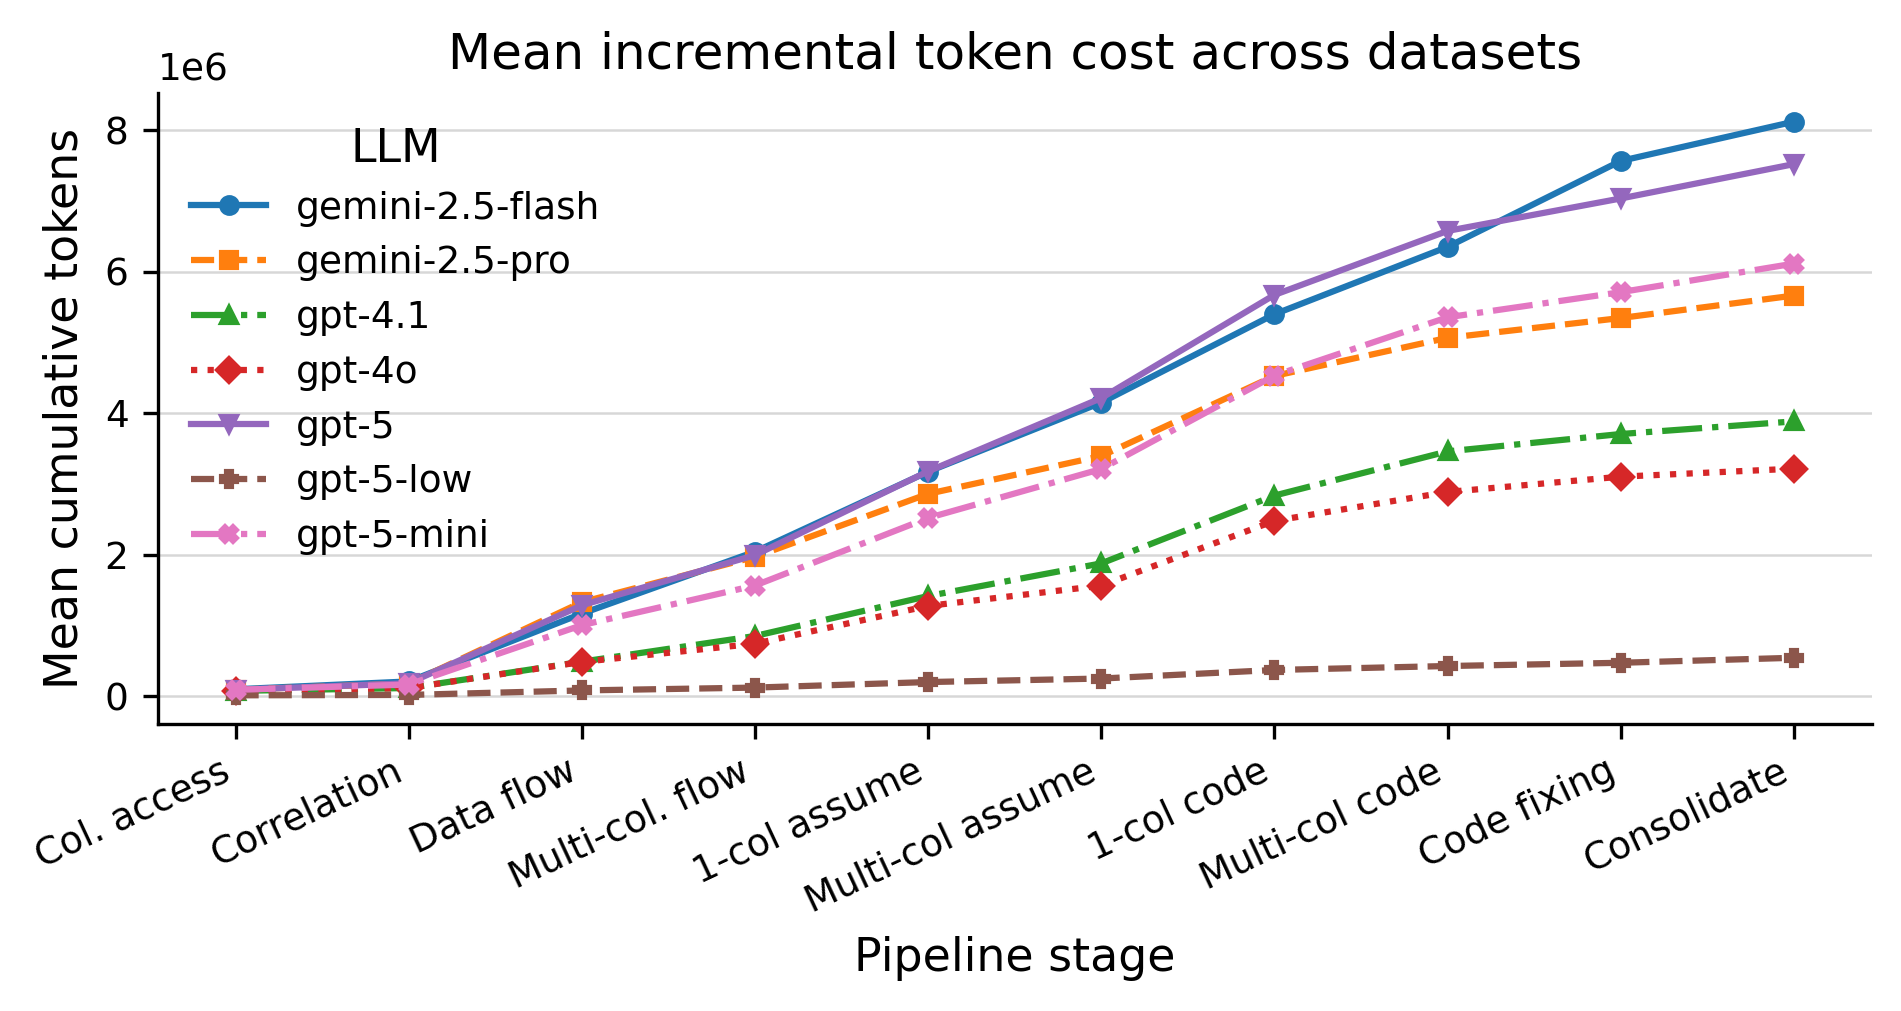

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------- 1. Global plot style ----------
mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

# ---------- 2. Stage ordering ----------
if isinstance(long_df["stage"].dtype, pd.CategoricalDtype):
    stages = list(long_df["stage"].cat.categories)
else:
    stages = sorted(long_df["stage"].unique())

stage_positions = np.arange(len(stages))

# Optional shorter labels
stage_label_map = {
    'column_access_detection': 'Col. access',
    'column_correlation_discovery': 'Correlation',
    'data_flow_inspection': 'Data flow',
    'multi_column_data_flow_inspection': 'Multi-col. flow',
    'single_column_assumption_generation': '1-col assume',
    'multi_column_assumption_generation': 'Multi-col assume',
    'single_column_code_generation': '1-col code',
    'multi_column_code_generation': 'Multi-col code',
    'code_fixing': 'Code fixing',
    'consolidate_constraints': 'Consolidate',
}
x_labels = [stage_label_map.get(s, s) for s in stages]

# ---------- 3. Line styles & markers ----------
line_styles = ['solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

# ---------- 4. Mean tokens per (llm_name, stage) ----------
df_mean = (
    long_df
    .groupby(["llm_name", "stage"], observed=False, as_index=False)
    .agg({"tokens": "mean"})
)

# ---------- 5. Complete grid over all (llm_name, stage) ----------
llms = df_mean["llm_name"].unique()
full_index = pd.MultiIndex.from_product(
    [llms, stages],
    names=["llm_name", "stage"]
)

df_mean_idx = df_mean.set_index(["llm_name", "stage"])
mean_complete = df_mean_idx.reindex(full_index).reset_index()

# ---------- 6. Cumulative mean tokens per LLM ----------
mean_complete["cum_tokens"] = (
    mean_complete
    .groupby("llm_name")["tokens"]
    .cumsum()
)

# ---------- 7. Plot mean incremental token cost ----------
plt.figure(figsize=(6.5, 3.5))

for i, (llm, df_llm) in enumerate(mean_complete.groupby("llm_name")):
    style = line_styles[i % len(line_styles)]
    marker = markers[i % len(markers)]

    plt.plot(
        stage_positions,
        df_llm["cum_tokens"].values,
        linestyle=style,
        marker=marker,
        linewidth=1.5,
        markersize=4,
        label=llm,
    )

plt.xticks(stage_positions, x_labels, rotation=25, ha="right")
plt.ylabel("Mean cumulative tokens")
plt.xlabel("Pipeline stage")
plt.title("Mean incremental token cost across datasets")

plt.grid(True, axis="y", linewidth=0.6, alpha=0.5)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(title="LLM", frameon=False, loc="upper left")
plt.tight_layout()

plt.savefig("mean_incremental_token_cost.pdf", dpi=300)
plt.show()